# Module #13 - Data acquisition from PubChem
Authors:

- Jaime Rodríguez-Guerra, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)

## Aim of this Module

In this notebook, you will learn how to search for compounds similar to an input SMILES in [PubChem](https://pubchem.ncbi.nlm.nih.gov/) with the API web service.

## References

* Literature:
    * PubChem 2019 update: [_Nucleic Acids Res._ (2019), __47__, D1102-1109](https://academic.oup.com/nar/article/47/D1/D1102/5146201)
    * PubChem in 2021: [_Nucleic Acids Res._(2021), __49__, D1388–D1395](https://academic.oup.com/nar/article/49/D1/D1388/5957164)
* Documentation: 
    * [PubChem Source Information](https://pubchem.ncbi.nlm.nih.gov/sources)
    * [PUG REST](https://pubchemdocs.ncbi.nlm.nih.gov/pug-rest)
    * [Programmatic Access](https://pubchemdocs.ncbi.nlm.nih.gov/programmatic-access)
    * [PubChem - Wikipedia](https://en.wikipedia.org/wiki/PubChem)

## Practical

In this section, we will discuss how to search PubChem based on a given query molecule using the PUG-REST access.

In [2]:
import time
from pathlib import Path
from urllib.parse import quote

from IPython.display import Markdown, Image
import requests
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import MolsToGridImage

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

### Simple examples for the PubChem API
Before querying PubChem for similar compounds, we provide some simple examples to show how to use the PubChem API. For more detail about the PubChem API, see [PUG-REST tutorial](https://pubchemdocs.ncbi.nlm.nih.gov/pug-rest-tutorial).

####  How to get the PubChem CID for a compound
For example, we will search for the PubChem Compound Identification (CID) for Aspirin by name.  

In [4]:
# Get PubChem CID by name
name = "aspirin"

url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{name}/cids/JSON"

r = requests.get(url)
r.raise_for_status()
response = r.json()
if "IdentifierList" in response:
    cid = response["IdentifierList"]["CID"][0]
else:
    raise ValueError(f"Could not find matches for compound: {name}")
print(f"PubChem CID for {name} is:\n{cid}")
# NBVAL_CHECK_OUTPUT

PubChem CID for aspirin is:
2244


#### Retrieve molecular properties based on a PubChem CID
We can get interesting properties for a compound through its PubChem CID, such as molecular weight, pKd, logP, etc. Here, we will search for the molecular weight for Aspirin.

In [5]:
# Get mol weight for aspirin
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/MolecularWeight/JSON"

r = requests.get(url)
r.raise_for_status()
response = r.json()

if "PropertyTable" in response:
    mol_weight = response["PropertyTable"]["Properties"][0]["MolecularWeight"]
else:
    raise ValueError(f"Could not find matches for PubChem CID: {cid}")
print(f"Molecular weight for {name} is:\n{mol_weight}")
# NBVAL_CHECK_OUTPUT

Molecular weight for aspirin is:
180.16


#### Depict a compound with PubChem

The 2D structure of Aspirin:

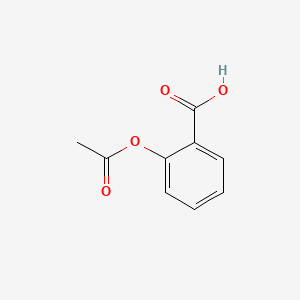

In [6]:
# Get PNG image from PubChem
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/PNG"

r = requests.get(url)
r.raise_for_status()

display(Markdown("The 2D structure of Aspirin:"))
display(Image(r.content))

### Query PubChem for similar compounds
Use a `SMILES` string of a query compound to search for similar compounds in PubChem.

> Tip: You can check **Module 1** to see how to do a similar operation with the ChEMBL database.

We define a function to query the PubChem service for similar compounds to the given one. The Tanimoto-based similarity between (2D) PubChem fingerprint will be calculated here. You can see [this paper](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-016-0163-1) for more details about similarity evaluation in PubChem, and the [PubChem fingerprint specification](https://ftp.ncbi.nlm.nih.gov/pubchem/specifications/pubchem_fingerprints.pdf) for the details about PubChem fingerprint.

#### 1. Determine a query compound
In the following steps, we will search compounds similar to FRAX597, an inhibitor for PAK1, from the PubChem service. You can also choose another compound which you are interested in.

The structure of FRAX597:


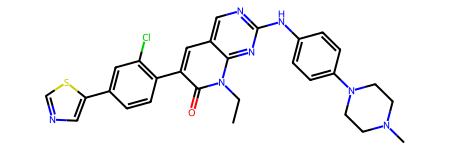

In [7]:
query = "CCN1C2=NC(=NC=C2C=C(C1=O)C3=C(C=C(C=C3)C4=CN=CS4)Cl)NC5=CC=C(C=C5)N6CCN(CC6)C"  # FRAX597
print("The structure of FRAX597:")
Chem.MolFromSmiles(query)

#### 2. Create task and get the job key

Input the canonical `SMILES` string for the given compound to create a new task, so we obtain a job key here. Note that this asynchronous API will not return the data immediately. In this case, the callback will be provided only when the requested resource is ready, which can be checked by the job key. So asynchronous requests are useful to work around certain slower operations. 

In [8]:
def query_pubchem_for_similar_compounds(smiles, threshold=75, n_records=10):
    """
    Query PubChem for similar compounds and return the job key.

    Parameters
    ----------
    smiles : str
        The canonical SMILES string for the given compound.
    threshold : int
        The threshold of similarity, default 75%. In PubChem, the default threshold is 90%.
    n_records : int
        The maximum number of feedback records.

    Returns
    -------
    str
        The job key from the PubChem web service.
    """
    escaped_smiles = quote(smiles).replace("/", ".")
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/similarity/smiles/{escaped_smiles}/JSON?Threshold={threshold}&MaxRecords={n_records}"
    r = requests.get(url)
    r.raise_for_status()
    key = r.json()["Waiting"]["ListKey"]
    return key

In [9]:
job_key = query_pubchem_for_similar_compounds(query)

#### 3. Download results when job finished
Check if the job finished within the time limit. The standard time limit in PubChem is 30 seconds (we can reset it). It means that if a request is not completed within the time limit, a timeout error will be returned. So, just wait patiently for the callback.

Then download results -  PubChem CIDs in this case -  when the job is finished.

In [10]:
def check_and_download(key, attempts=30):
    """
    Check job status and download PubChem CIDs when the job finished

    Parameters
    ----------
    key : str
        The job key of the PubChem service.
    attempts : int
        The time waiting for the feedback from the PubChem service.

    Returns
    -------
    list
        The PubChem CIDs of similar compounds.
    """
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/listkey/{key}/cids/JSON"
    print(f"Querying for job {key} at URL {url}...", end="")
    while attempts:
        r = requests.get(url)
        r.raise_for_status()
        response = r.json()
        if "IdentifierList" in response:
            cids = response["IdentifierList"]["CID"]
            break
        attempts -= 1
        print(".", end="")
        time.sleep(10)
    else:
        raise ValueError(f"Could not find matches for job key: {key}")
    return cids

In [11]:
similar_cids = check_and_download(job_key)

Querying for job 803996653385538155 at URL https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/listkey/803996653385538155/cids/JSON....

#### 4. Get canonical SMILES for resulting molecules

In [12]:
def smiles_from_pubchem_cids(cids):
    """
    Get the canonical SMILES string from the PubChem CIDs.

    Parameters
    ----------
    cids : list
        A list of PubChem CIDs.

    Returns
    -------
    list
        The canonical SMILES strings of the PubChem CIDs.
    """
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{','.join(map(str, cids))}/property/CanonicalSMILES/JSON"
    print("URL: " +url)
    r = requests.get(url)
    r.raise_for_status()
    return [item["ConnectivitySMILES"] for item in r.json()["PropertyTable"]["Properties"]]

In [13]:
similar_smiles = smiles_from_pubchem_cids(similar_cids)

URL: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/3062316,10280735,50905713,25161177,10074640,5311104,44610678,9952773,89655386,4369496/property/CanonicalSMILES/JSON


Then, we create the RDKit molecules and depict them.

In [14]:
query_results_df = pd.DataFrame({"smiles": similar_smiles, "CIDs": similar_cids})
PandasTools.AddMoleculeColumnToFrame(query_results_df, smilesCol="smiles")
query_results_df.head(5)

,smiles,CIDs,ROMol
0,CC1=C(C(=CC=C1)Cl)NC(=O)C2=CN=C(S2)NC3=CC(=NC(...,3062316,<rdkit.Chem.rdchem.Mol object at 0x000001F17D3...
1,CN1CCC2=C(C1)SC(=N2)C(=O)NC3CC(CCC3NC(=O)C(=O)...,10280735,<rdkit.Chem.rdchem.Mol object at 0x000001F17D3...
2,CC(C1=CC2=C(C(=CC=C2)Cl)C(=O)N1C3=CC=CC=C3)NC4...,50905713,<rdkit.Chem.rdchem.Mol object at 0x000001F17D3...
3,CC(C1=NC=C(S1)C(=O)NC2=NC=C(C(=C2)C(F)(F)F)Cl)...,25161177,<rdkit.Chem.rdchem.Mol object at 0x000001F17D3...
4,CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C...,10074640,<rdkit.Chem.rdchem.Mol object at 0x000001F17D3...


#### 5. Show the results
Show the compounds with images using RDKit's drawing functions.

In [15]:
def multi_preview_smiles(query_smiles, query_name, similar_molecules_pd):
    """
    Show query and similar compounds in 2D structure representation.

    Parameters
    ----------
    query_smiles : str
        The SMILES string of query compound.
    query_name : str
        The name of query compound.
    similar_molecules_pd : pandas
        The pandas DataFrame which contains the SMILES string and CIDs of similar molecules.

    Returns
    -------
    MolsToGridImage
    """

    legends = [f"PubChem CID: {str(s)}" for s in similar_molecules_pd["CIDs"].tolist()]
    molecules = [Chem.MolFromSmiles(s) for s in similar_molecules_pd["smiles"]]
    query_smiles = Chem.MolFromSmiles(query_smiles)
    return MolsToGridImage(
        [query_smiles] + molecules,
        molsPerRow=3,
        subImgSize=(300, 300),
        maxMols=len(molecules),
        legends=([query_name] + legends),
        useSVG=True,
    )

The results of querying similar compounds for FRAX597:


C:\Users\amrut\miniconda3\envs\teachopencadd-env\lib\site-packages\rdkit\Chem\Draw\IPythonConsole.py:261: UserWarning: Truncating the list of molecules to be displayed to 10. Change the maxMols value to display more.
  warnings.warn(


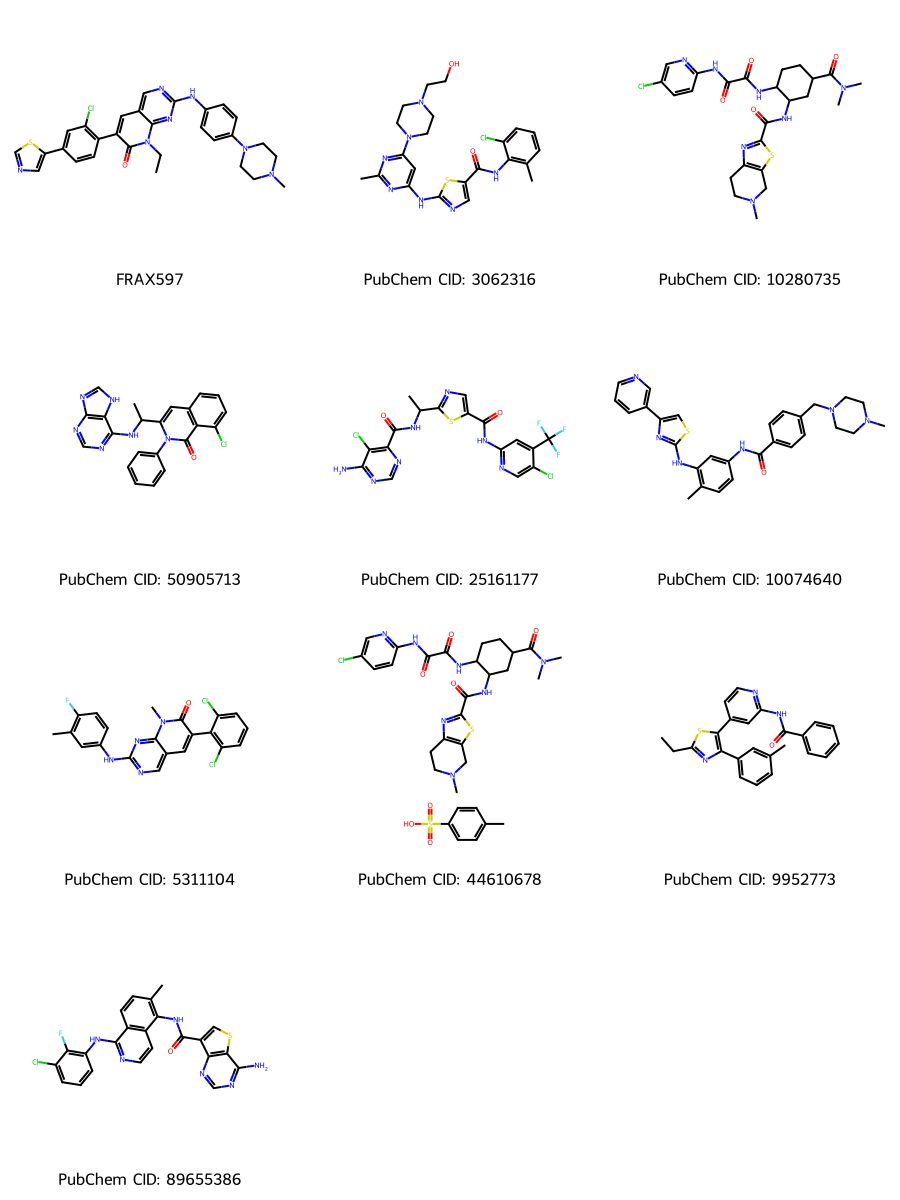

In [16]:
print("The results of querying similar compounds for FRAX597:")
img = multi_preview_smiles(query, "FRAX597", query_results_df)
img

## Discussion

In this notebook, you have learned how to access and search similar compounds from the PubChem database via the PUG-REST programmatic access. Is it convenient? PUG-REST can do more than that. See [PUG-REST](https://pubchemdocs.ncbi.nlm.nih.gov/pug-rest-tutorial) to get more power! 
